# Vibrational strong coupling with liquid water: Unix socket

Here, we introduce how to use MaxwellLink to run cavity molecular dynamics (CavMD) simulations of liquid water under vibrational strong coupling.

## 1. Setting up the socket communication layer

Using the TCP socket requires setting the `hostname` and `port number`. On a local machine, we can use the helper function `get_available_host_port()` from **MaxwellLink** to obtain these two pieces of information. Then, we initialize a `SocketHub` instance to provide the socket communication in **MaxwellLink**.

In [1]:
import numpy as np
import maxwelllink as mxl

address = "socket_cavmd"
hub = mxl.SocketHub(unixsocket=address, timeout=10.0, latency=1e-5)

## 2. Bind Molecule and EM solver to the SocketHub

Then, we create a `Molecule` instance to define the information of this molecule in the EM simulation environment. We also need to setup the EM solver (**MEEP**) as a classical single mode cavity using `mxl.SingleModeSimulation`.

In [2]:
# the rescaling 0.73 is to account for the difference between the TIP4P water model verus that from a straightforward
# sum_i Q_i * r_i calculation, where the oxygen atom is used for the position instead of using the M charge site.
# In other words, the dipole and dmudt calculation from MD driver needs to be rescaled by 0.73 to match the real TIP4P
# water model values (used in i-pi CavMD).
molecule = mxl.Molecule(
    hub=hub,
    rescaling_factor=0.73,
)

au_to_cminverse = 219474.63

frequency_au = 3550 / au_to_cminverse
coupling_strength = 4e-4
print(f"Coupling strength: {coupling_strength:.3e} au")
damping_au = 0e-4
fs_to_au = 41.3413745758
dt_fs = 0.5
dt_au = dt_fs * fs_to_au

sim = mxl.SingleModeSimulation(
    hub=hub,
    molecules=[molecule],
    frequency_au=frequency_au,
    coupling_strength=coupling_strength,
    damping_au=damping_au,
    coupling_axis="z",
    drive=0.0,
    dt_au=dt_au,
    record_history=True,
    include_dse=True,
)


[Init Molecule] Under socket mode, registered molecule with ID 0
Coupling strength: 4.000e-04 au


## 3. Python way to launch LAMMPS on a separate terminal

Generally, using the Socket Interface requires launching the EM simulation in one terminal and then starting the molecular driver simulation in a separate terminal. To avoid opening a second terminal, below we introduce a Python helper function `launch_lmp(...)`, which will launch LAMMPS (the `lmp_mxl` binary file) from Python (so we can stay within this notebook to finish this tutorial).

The LAMMPS code performs a 10-ps NVE liquid water simulation. The `fix mxl` command in the LAMMPS input file communicates between LAMMPS and MaxwellLink.

In a 2021 MacBook Pro M1, this simulation takes approximately 1.5 minutes.

In [3]:
import shlex
import subprocess
import time


def launch_lmp(address: str, sleep_time: float = 0.5):
    cmd = (
        f"./lmp_input/launch_lmp_xml.sh {address} "
    )
    print('Launching LMP via subprocess...')
    print('If you prefer to run it manually, execute:')
    print('  ' + cmd)
    argv = shlex.split(cmd)
    proc = subprocess.Popen(argv)
    time.sleep(sleep_time)
    return proc

launch_lmp(address)

sim.run(steps=int(10000/dt_fs))    

Launching LMP via subprocess...
If you prefer to run it manually, execute:
  ./lmp_input/launch_lmp_xml.sh socket_cavmd 
Preparing LAMMPS input files with port socket_cavmd...
LAMMPS (29 Aug 2024 - Update 1)
Reading data file ...
  orthogonal box = (0 0 0) to (35.233 35.233 35.233)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  648 atoms
  scanning bonds ...
  2 = max bonds/atom
  scanning angles ...
  1 = max angles/atom
  orthogonal box = (0 0 0) to (35.233 35.233 35.233)
  1 by 1 by 1 MPI processor grid
  reading bonds ...
  432 bonds
  reading angles ...
  216 angles
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
     2 = max # of 1-2 neighbors
     1 = max # of 1-3 neighbors
     1 = max # of 1-4 neighbors
     2 = max # of special neighbors
  special bonds CPU = 0.000 seconds
  read_data CPU = 0.004 seconds
[MaxwellLink] Will reset initial permanent dipole to zero.

CITE-C

## 4. Retrieve molecular simulation data

After the simulation, we can retrieve molecular simulation data from `molecule.additional_data_history`, a Python list which stores the molecular information sent from the driver code at each step of the simulation.

In [4]:
for data in molecule.additional_data_history[0:5]:
    print(data)

{'time_au': 20.670687908214944, 'mux_au': -0.123007369475225, 'muy_au': 0.414604211280153, 'muz_au': -0.133248553303204, 'mux_m_au': -0.123007369475225, 'muy_m_au': 0.414604211280153, 'muz_m_au': -0.133248553303204, 'energy_au': -2.627474698462433, 'temp_K': 279.0533752828051, 'pe_au': -3.486441311034758, 'ke_au': 0.858966612572326}
{'time_au': 41.34137581642989, 'mux_au': -0.201399274240348, 'muy_au': 0.631882469775508, 'muz_au': -0.20536667495551, 'mux_m_au': -0.201399274240348, 'muy_m_au': 0.631882469775508, 'muz_m_au': -0.20536667495551, 'energy_au': -2.627623458160897, 'temp_K': 279.70744016291457, 'pe_au': -3.488603376947136, 'ke_au': 0.860979918786238}
{'time_au': 62.01206372464483, 'mux_au': -0.282723361978718, 'muy_au': 0.792759099858962, 'muz_au': -0.260936561671233, 'mux_m_au': -0.282723361978718, 'muy_m_au': 0.792759099858962, 'muz_m_au': -0.260936561671233, 'energy_au': -2.62845421472813, 'temp_K': 282.51250869263663, 'pe_au': -3.498068539783659, 'ke_au': 0.869614325055529

## 5. Plot IR spectrum

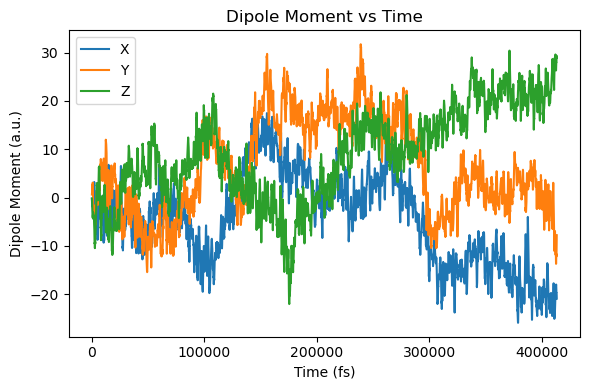

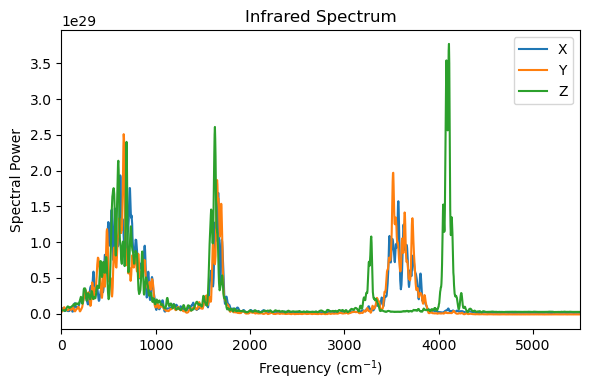

In [5]:
from maxwelllink.tools import ir_spectrum
import matplotlib.pyplot as plt

mux = np.array([ad["mux_m_au"] for ad in molecule.additional_data_history])[1:-1]
muy = np.array([ad["muy_m_au"] for ad in molecule.additional_data_history])[1:-1]
muz = np.array([ad["muz_m_au"] for ad in molecule.additional_data_history])[1:-1]
t = np.array([ad["time_au"] for ad in molecule.additional_data_history])[1:-1]

plt.figure(figsize=(6, 4))
plt.plot(t, mux, label="X")
plt.plot(t, muy, label="Y")
plt.plot(t, muz, label="Z")
plt.xlabel("Time (fs)")
plt.ylabel("Dipole Moment (a.u.)")
plt.title("Dipole Moment vs Time")
plt.legend()
plt.tight_layout()
plt.show()

freq, sp_x = ir_spectrum(mux, dt_fs, field_description="square")
freq, sp_y = ir_spectrum(muy, dt_fs, field_description="square")
freq, sp_z = ir_spectrum(muz, dt_fs, field_description="square")

plt.figure(figsize=(6, 4))
plt.plot(freq, sp_x, label="X")
plt.plot(freq, sp_y, label="Y")
plt.plot(freq, sp_z, label="Z")
plt.xlim(0, 5500)
plt.xlabel("Frequency (cm$^{-1}$)")
plt.ylabel("Spectral Power")
plt.title("Infrared Spectrum")
plt.legend()
plt.tight_layout()

plt.show()



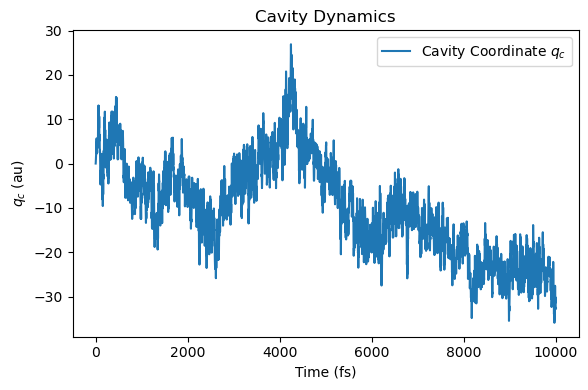

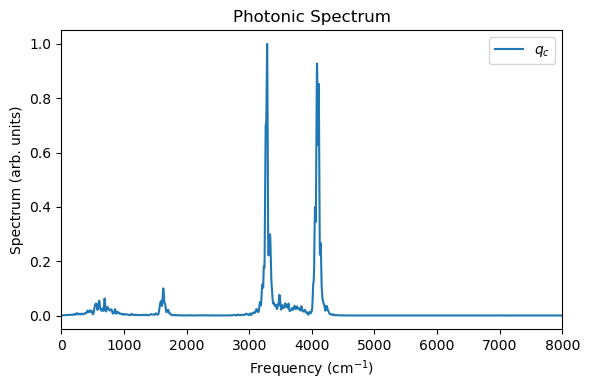

In [6]:
# plot cavity dynamics
au_to_fs = 41.3413745758
t = np.array(sim.time_history) / au_to_fs
# qc[0] is the z-direction cavity coordinate
qc = np.array([qc[-1] for qc in sim.qc_history])

freq, sp_qc = ir_spectrum(qc, dt_fs, field_description="square")


plt.figure(figsize=(6, 4))
plt.plot(t, qc, label="Cavity Coordinate $q_c$")
plt.xlabel("Time (fs)")
plt.ylabel("$q_c$ (au)")
plt.title("Cavity Dynamics")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
plt.plot(freq, sp_qc / np.max(sp_qc), label="$q_c$")
plt.xlim(0, 8000)
plt.xlabel("Frequency (cm$^{-1}$)")
plt.ylabel("Spectrum (arb. units)")
plt.title("Photonic Spectrum")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Energy conservation analysis

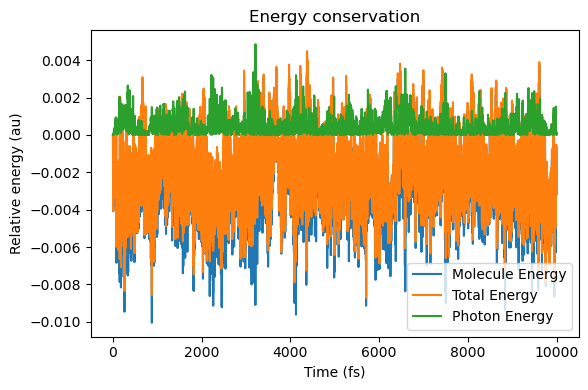

In [7]:
energy_molecule = np.array([ad["energy_au"] for ad in molecule.additional_data_history])
energy_tot = np.array(sim.energy_history)
energy_photon = energy_tot - energy_molecule

plt.figure(figsize=(6, 4))
plt.plot(t, energy_molecule - energy_molecule[0], label="Molecule Energy")
plt.plot(t, energy_tot - energy_tot[0], label="Total Energy")
plt.plot(t, energy_photon - energy_photon[0], label="Photon Energy")
plt.xlabel("Time (fs)")
plt.ylabel("Relative energy (au)")
plt.title("Energy conservation")
plt.legend()
plt.tight_layout()
plt.show()
